# Quantum Support Vector Machine - Breast Cancer Prediction
This notebook has been updated to use the modern Qiskit Machine Learning and Algorithms libraries, replacing the deprecated `qiskit-aqua`.

### Install Dependencies
If you are running this locally, ensure you have the following installed:
```bash
pip install qiskit qiskit-machine-learning qiskit-algorithms qiskit-aer matplotlib scikit-learn
```

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_algorithms.utils import algorithm_globals
from qiskit.circuit.library import zz_feature_map
from qiskit_aer import AerSimulator

try:
    # This is for Qiskit 1.x+
    from qiskit.primitives import StatevectorSampler as Sampler
except ImportError:
    try:
        # This is for older Qiskit versions
        from qiskit.primitives import Sampler
    except ImportError:
        # Final fallback for certain 1.x configurations
        from qiskit_aer.primitives import Sampler


# Set seed for reproducibility
seed = 10598
algorithm_globals.random_seed = seed
print("All modules imported successfully.")

All modules imported successfully.


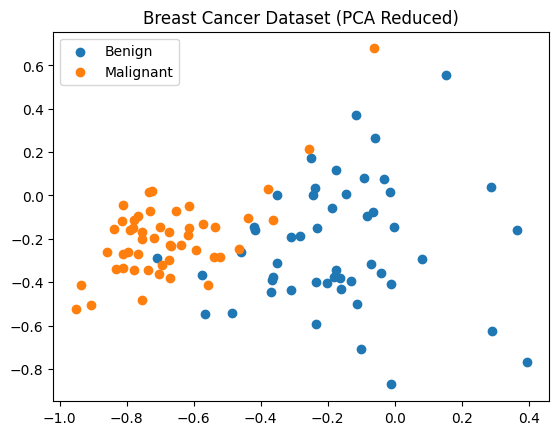

In [30]:
def load_and_preprocess_data(n_features, training_size, test_size, PLOT_DATA=True):
    class_labels = ['Benign', 'Malignant']
    cancer = datasets.load_breast_cancer()
    
    # Split dataset into 70% training, 30% testing
    X_train, X_test, y_train, y_test = train_test_split(
        cancer.data, cancer.target, test_size=0.3, random_state=109
    )
    
    # Standardize features
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Dimensionality reduction with PCA to match number of qubits
    pca = PCA(n_components=n_features).fit(X_train)
    X_train = pca.transform(X_train)
    X_test = pca.transform(X_test)

    # Scale data to [-1, 1]
    samples = np.append(X_train, X_test, axis=0)
    minmax_scale = MinMaxScaler((-1, 1)).fit(samples)
    X_train = minmax_scale.transform(X_train)
    X_test = minmax_scale.transform(X_test)

    # Subset data for training/testing speed
    # Selecting first N samples for each class
    def get_subset(X, y, size):
        indices = []
        for label in [0, 1]:
            label_indices = np.where(y == label)[0][:size]
            indices.extend(label_indices)
        return X[indices], y[indices]

    X_train_sub, y_train_sub = get_subset(X_train, y_train, training_size // 2)
    X_test_sub, y_test_sub = get_subset(X_test, y_test, test_size // 2)

    if PLOT_DATA:
        for label_val, label_name in enumerate(class_labels):
            plt.scatter(
                X_train_sub[y_train_sub == label_val, 0],
                X_train_sub[y_train_sub == label_val, 1],
                label=label_name
            )
        plt.title("Breast Cancer Dataset (PCA Reduced)")
        plt.legend()
        plt.show()

    return X_train_sub, y_train_sub, X_test_sub, y_test_sub, class_labels

# Parameters
n_qubits = 2
train_size = 100
test_size =20

X_train, y_train, X_test, y_test, class_labels = load_and_preprocess_data(n_qubits, train_size, test_size)

In [31]:
# 1. Define the Feature Map (Equivalent to SecondOrderExpansion in Aqua)
#feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=2, entanglement='linear')
feature_map = zz_feature_map(n_qubits, reps=2, entanglement='linear')

# 2. Define the Quantum Kernel
# We use a Sampler primitive and the ComputeUncompute fidelity
sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)
kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

# 3. Create the Quantum Support Vector Classifier (QSVC)
qsvc = QSVC(quantum_kernel=kernel)

# 4. Training
print("Training QSVM...")
qsvc.fit(X_train, y_train)

# 5. Prediction
print("Predicting...")
predictions = qsvc.predict(X_test)
accuracy = qsvc.score(X_test, y_test)

print("\n--- Results ---")
print(f"Ground Truth: {y_test}")
print(f"Predictions:  {predictions}")
print(f"Accuracy:     {accuracy:.2f}")

Training QSVM...
Predicting...

--- Results ---
Ground Truth: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Predictions:  [0 0 1 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 1 1]
Accuracy:     0.75
